code implementation for the notes at this repo mech interp/anthropic/1-superposition.md


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim = 2):
        super().__init__()
        # W: (hidden_dim, input_dim) - each column W_i is a feature's direction
        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.1)

    def forward(self, x):
        # x: (batch, input_dim)
        # encode: (batch, input_dim) @ (input_dim, hidden_dim) -> (batch, hidden_dim)
        h = x @ self.W.T
        # decode: (batch, hidden_dim) @ (hidden_dim, input_dim) -> (batch, input_dim)
        # using W transpose means decoder weight is always W.T.T = W
        x_hat = h @ self.W
        return x_hat

In [3]:
class ReluAutoEncoder(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim = 2):
        super().__init__()
        # W: (hidden_dim, input_dim) - each column W_i is a feature's direction
        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.1)

    def forward(self, x):
        # x: (batch, input_dim)
        # encode: (batch, input_dim) @ (input_dim, hidden_dim) -> (batch, hidden_dim)
        h = x @ self.W.T
        # decode: (batch, hidden_dim) @ (hidden_dim, input_dim) -> (batch, input_dim)
        # using W transpose means decoder weight is always W.T.T = W
        x_hat = h @ self.W
        return torch.relu(x_hat)

In [4]:
class PrivelegedAutoEncoder(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim = 2):
        super().__init__()
        # W: (hidden_dim, input_dim) - each column W_i is a feature's direction
        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.1)

    def forward(self, x):
        # x: (batch, input_dim)
        # encode: (batch, input_dim) @ (input_dim, hidden_dim) -> (batch, hidden_dim)
        h = x @ self.W.T
        h = torch.relu(h)
        # decode: (batch, hidden_dim) @ (hidden_dim, input_dim) -> (batch, input_dim)
        # using W transpose means decoder weight is always W.T.T = W
        x_hat = h @ self.W
        return x_hat

In [5]:
def generate_data(input_dim=5, n_samples=1000, sparsity=0):
    # torch.rand gives uniform [0, 1) - all positive like the paper
    data = torch.rand(n_samples, input_dim)
    mask = (torch.rand(n_samples, input_dim) > sparsity).float()
    data = data * mask
    return data

In [6]:
zero_sparse_data = generate_data(input_dim = 5, n_samples = 100, sparsity = 0)
eighty_sparse_data = generate_data(input_dim = 5, n_samples = 100, sparsity = 0.8)
ninety_sparse_data = generate_data(input_dim = 5, n_samples = 100, sparsity = 0.9)



In [7]:
def train_autoencoder(model, data, lr=0.01, epochs=1000):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        x_hat = model(data)
        loss = nn.MSELoss()(x_hat, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"{model.__class__.__name__} final loss: {loss.item():.6f}")

In [8]:
colors = ['#E8C547', '#A4C94A', '#4AB89D', '#4A90C9', '#8B5CF6']

def plot_features(model, title="Feature Directions", ax=None):
    W = model.W.detach().numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    
    for i in range(W.shape[1]):
        ax.plot([0, W[0, i]], [0, W[1, i]], c=colors[i], linewidth=2)
        ax.scatter(W[0, i], W[1, i], c=colors[i], s=80)
    
    limit = max(abs(W).max() * 1.2, 0.5)
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', alpha=0.3); ax.axvline(0, color='gray', alpha=0.3)
    ax.set_title(title)

In [9]:
# train 9 models: 3 architectures x 3 sparsity levels
sparsities = [0, 0.8, 0.9]
datasets = [generate_data(sparsity=s) for s in sparsities]

models = {}
for s, data in zip(sparsities, datasets):
    models[f'auto_{s}'] = AutoEncoder()
    models[f'relu_{s}'] = ReluAutoEncoder()
    models[f'priv_{s}'] = PrivelegedAutoEncoder()
    train_autoencoder(models[f'auto_{s}'], data)
    train_autoencoder(models[f'relu_{s}'], data)
    train_autoencoder(models[f'priv_{s}'], data)

AutoEncoder final loss: 0.049413
ReluAutoEncoder final loss: 0.049741
PrivelegedAutoEncoder final loss: 0.049210
AutoEncoder final loss: 0.032723
ReluAutoEncoder final loss: 0.015676
PrivelegedAutoEncoder final loss: 0.032917
AutoEncoder final loss: 0.017707
ReluAutoEncoder final loss: 0.006638
PrivelegedAutoEncoder final loss: 0.017720


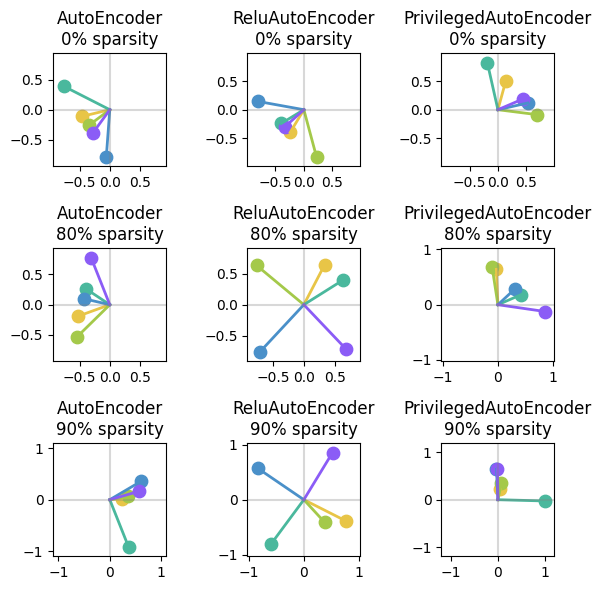

In [10]:
# plot all 9 models in a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
arch_names = ['auto', 'relu', 'priv']
arch_labels = ['AutoEncoder', 'ReluAutoEncoder', 'PrivilegedAutoEncoder']

for row, s in enumerate(sparsities):
    for col, (arch, label) in enumerate(zip(arch_names, arch_labels)):
        plot_features(models[f'{arch}_{s}'], f'{label}\n{int(s*100)}% sparsity', ax=axes[row, col])

plt.tight_layout(); plt.show()

In [11]:
# walkthrough for ReluAutoEncoder trained on 80% sparsity
model = models['relu_0.8']
W = model.W.detach()

print("W (hidden x features):")
print(W.numpy().round(3))
print()

for i in range(5):
    x = torch.zeros(5)
    x[i] = 1.0  # one-hot
    
    h = x @ W.T                    # encode
    pre_relu = h @ W               # decode before relu
    post_relu = torch.relu(pre_relu)  # decode after relu
    
    print(f"feature {i}: {x.numpy().astype(int)} -> h={h.numpy().round(3)} -> pre={pre_relu.numpy().round(3)} -> post={post_relu.numpy().round(3)}")

W (hidden x features):
[[ 0.338 -0.764  0.63  -0.71   0.681]
 [ 0.649  0.636  0.396 -0.763 -0.716]]

feature 0: [1 0 0 0 0] -> h=[0.338 0.649] -> pre=[ 0.535  0.154  0.47  -0.735 -0.235] -> post=[0.535 0.154 0.47  0.    0.   ]
feature 1: [0 1 0 0 0] -> h=[-0.764  0.636] -> pre=[ 0.154  0.989 -0.229  0.058 -0.976] -> post=[0.154 0.989 0.    0.058 0.   ]
feature 2: [0 0 1 0 0] -> h=[0.63  0.396] -> pre=[ 0.47  -0.229  0.554 -0.75   0.145] -> post=[0.47  0.    0.554 0.    0.145]
feature 3: [0 0 0 1 0] -> h=[-0.71  -0.763] -> pre=[-0.735  0.058 -0.75   1.087  0.063] -> post=[0.    0.058 0.    1.087 0.063]
feature 4: [0 0 0 0 1] -> h=[ 0.681 -0.716] -> pre=[-0.235 -0.976  0.145  0.063  0.976] -> post=[0.    0.    0.145 0.063 0.976]
